# Is UPI Changing the Way India Pays?

# EDA Question 1

How have different payment methods evolved since 2019?

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
payments = pd.read_csv("../data/processed/payments_master.csv")

In [4]:
payments.head()

,Month,UPI_Volume_inlakhs,UPI_Value_inCr,Credit_Volume_inlakhs,Credit_Value_inCr,Debit_Volume_inlakhs,Debit_Value_inCr,ATM_Debit_Volume_inlakhs,ATM_Debit_Value_inCr
0,2019-11-01,12187.70742,189229.089108,1762.12447,60130.248377,4180.838165,58208.685669,6236.886457,281337.849821
1,2019-12-01,13084.01713,202520.758566,2036.63822,65735.760462,4448.748800,62752.449627,6453.495660,289534.904391
2,2020-01-01,13050.19232,216242.974143,2017.27299,66572.861030,4500.845880,62871.186278,6495.686000,294174.321869
3,2020-02-01,13256.93237,222516.950030,1882.94000,62147.000000,4245.744090,58560.852133,6148.832000,281926.943762
4,2020-03-01,12468.44550,206462.307026,1638.57148,50574.150841,3608.125800,48208.950792,5409.610450,247428.946235


In [5]:
payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Month                     77 non-null     object 
 1   UPI_Volume_inlakhs        77 non-null     float64
 2   UPI_Value_inCr            77 non-null     float64
 3   Credit_Volume_inlakhs     77 non-null     float64
 4   Credit_Value_inCr         77 non-null     float64
 5   Debit_Volume_inlakhs      77 non-null     float64
 6   Debit_Value_inCr          77 non-null     float64
 7   ATM_Debit_Volume_inlakhs  77 non-null     float64
 8   ATM_Debit_Value_inCr      77 non-null     float64
dtypes: float64(8), object(1)
memory usage: 5.5+ KB


In [6]:
payments['Month'] = pd.to_datetime(payments['Month'])

In [7]:
payments[['UPI_Volume_inlakhs','Credit_Volume_inlakhs','Debit_Volume_inlakhs','ATM_Debit_Volume_inlakhs']].describe()

,UPI_Volume_inlakhs,Credit_Volume_inlakhs,Debit_Volume_inlakhs,ATM_Debit_Volume_inlakhs
count,77.000000,77.000000,77.000000,77.000000
mean,93119.256524,2884.561451,2421.760606,5253.102946
std,66881.578168,1252.618155,1049.750962,639.591396
min,9995.743760,768.532330,917.122000,2935.257920
25%,28075.160000,1884.239840,1423.935480,4734.614800
50%,78288.950000,2556.465050,2382.495730,5428.470350
75%,149630.470000,3900.493240,3315.647750,5685.103990
max,226411.080000,5774.765000,4500.845880,6495.686000


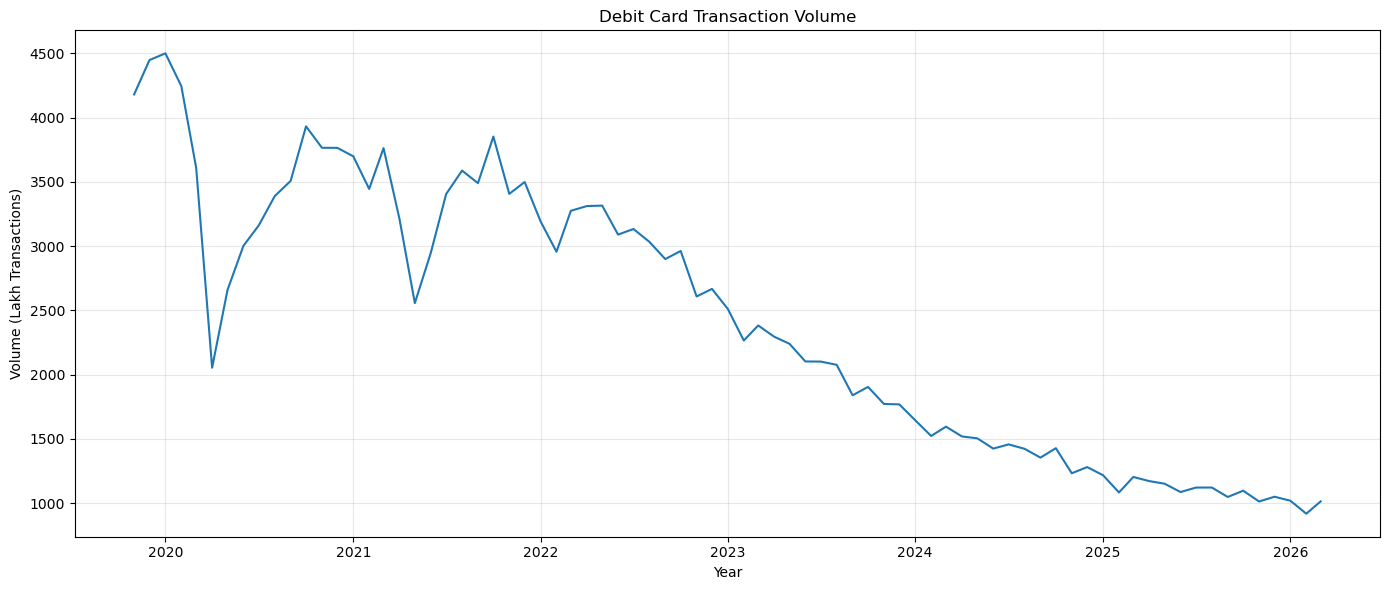

In [8]:
plt.figure(figsize=(14,6))
plt.plot(
payments['Month'],
    payments['Debit_Volume_inlakhs']
)
plt.title('Debit Card Transaction Volume')
plt.xlabel('Year')
plt.ylabel('Volume (Lakh Transactions)')

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Observation

Debit card transaction volume has declined substantially since 2020. After recovering from the initial COVID-19 shock, transaction volume continued to trend downward through 2026.

This suggests that debit cards may have lost relevance as a retail payment instrument during the same period in which UPI adoption accelerated.

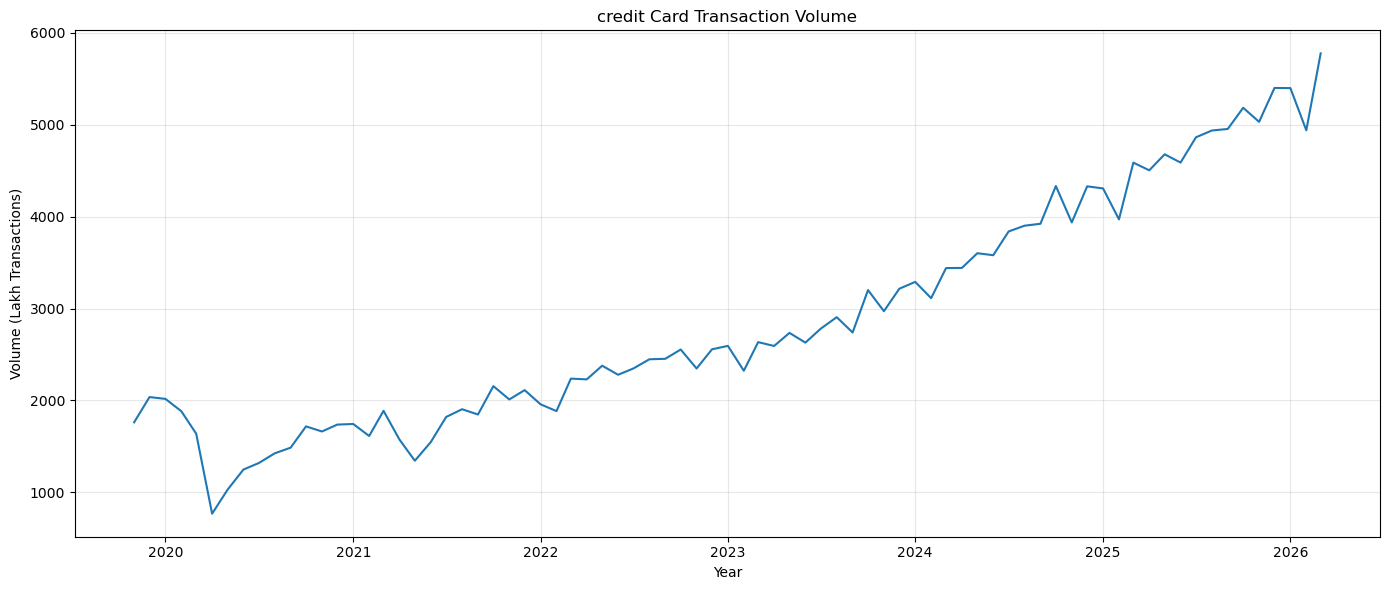

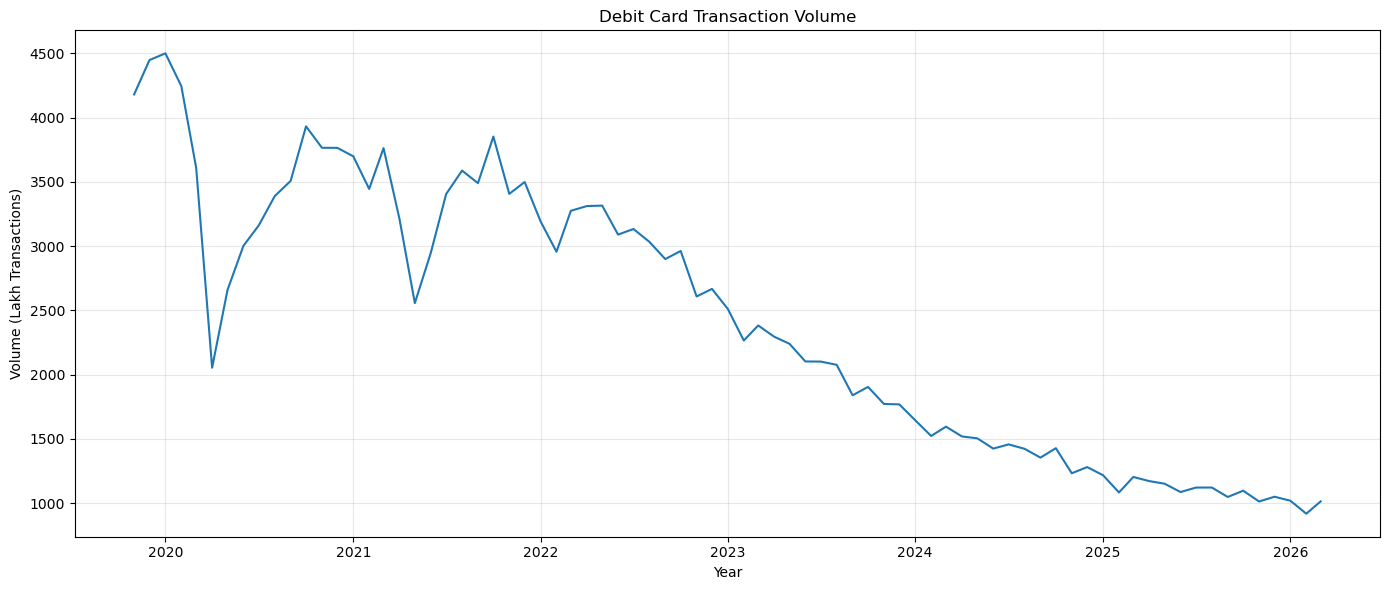

In [9]:



##



### Observation

Credit card transaction volume increased consistently throughout the period, reaching its highest level by 2026.

This suggests that UPI growth did not suppress all alternative payment methods. Instead, credit cards continued to expand alongside UPI, likely serving different consumer needs and transaction contexts.

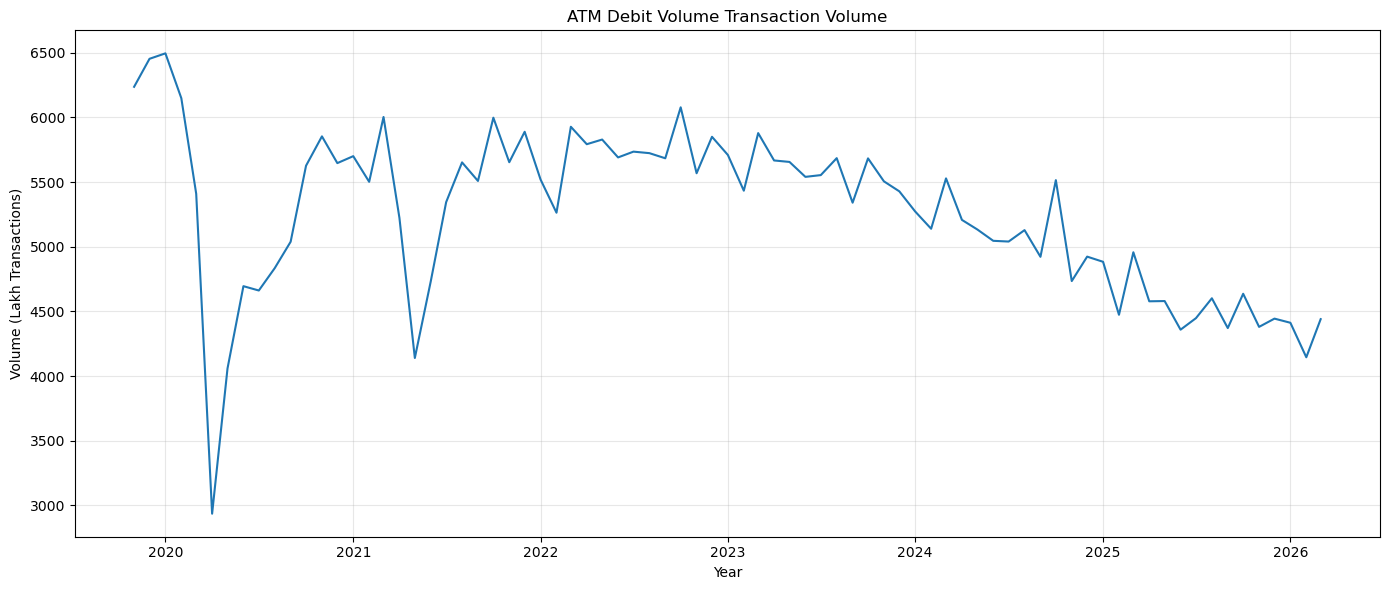

In [21]:
plt.figure(figsize=(14,6))
plt.plot(
payments['Month'],
    payments['ATM_Debit_Volume_inlakhs']
)
plt.title('ATM Debit Volume Transaction Volume')
plt.xlabel('Year')
plt.ylabel('Volume (Lakh Transactions)')

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Observation

ATM cash withdrawals using debit cards exhibit a gradual downward trend between 2020 and 2026.

This may indicate a reduction in cash dependency as digital payment channels became increasingly accessible and widely adopted.

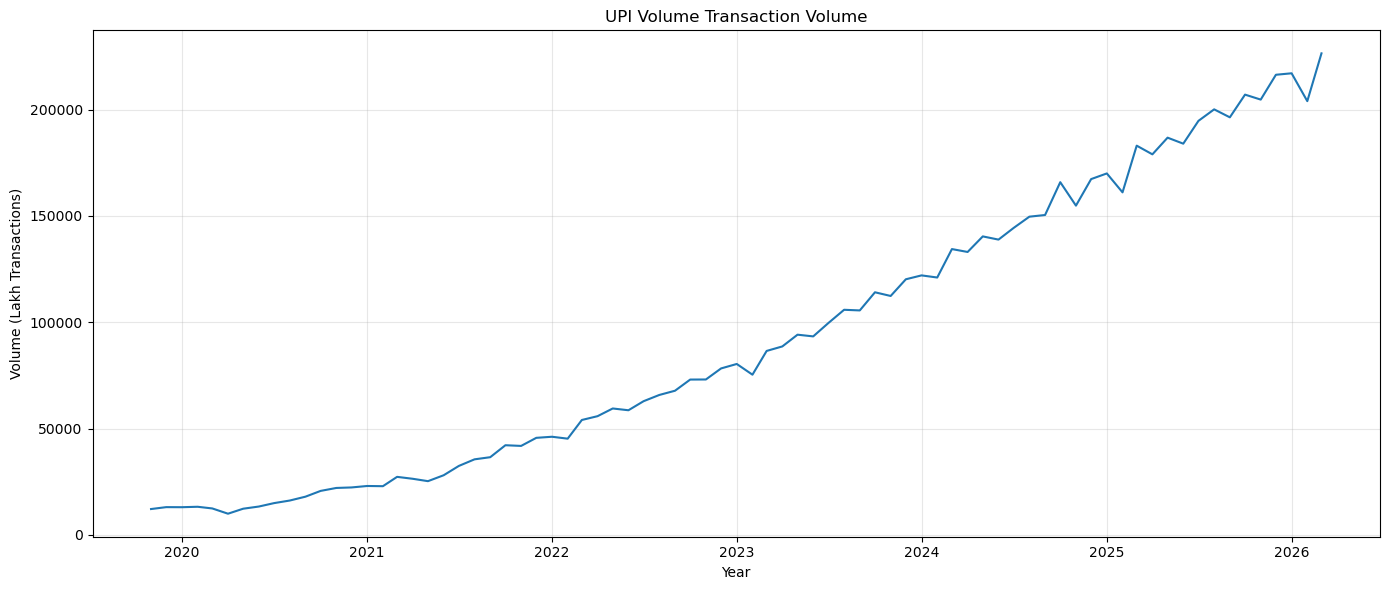

In [22]:
plt.figure(figsize=(14,6))
plt.plot(
payments['Month'],
    payments['UPI_Volume_inlakhs']
)
plt.title('UPI Volume Transaction Volume')
plt.xlabel('Year')
plt.ylabel('Volume (Lakh Transactions)')

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Observation

UPI transaction volume increased dramatically between 2019 and 2026, far outpacing the growth of other payment methods.

While debit card transactions and ATM withdrawals declined over the same period, credit card usage continued to increase. This suggests that UPI's rise may have had an uneven impact across payment channels rather than uniformly replacing all alternatives.

### Observation

All payment methods experienced a significant decline during the initial COVID-19 lockdown period in 2020, indicating a broad disruption in economic and consumer activity.

However, the decline was temporary, and transaction volumes recovered as economic activity resumed.

In [30]:
correlation_summary = pd.DataFrame({
    'Payment Method': [
        'Debit Cards',
        'ATM Debit Withdrawals',
        'Credit Cards'
    ],
    'Correlation with UPI Volume': [
        payments['UPI_Volume_inlakhs'].corr(payments['Debit_Volume_inlakhs']),
        payments['UPI_Volume_inlakhs'].corr(payments['ATM_Debit_Volume_inlakhs']),
        payments['UPI_Volume_inlakhs'].corr(payments['Credit_Volume_inlakhs'])
    ]
})

correlation_summary

,Payment Method,Correlation with UPI Volume
0,Debit Cards,-0.924921
1,ATM Debit Withdrawals,-0.472596
2,Credit Cards,0.986010


UPI transaction volume shows a strong negative correlation with debit card transaction volume (-0.925). This suggests that the rise of UPI coincided with a substantial decline in debit card usage during the study period.

While this does not prove causation, it provides strong evidence that debit card payments may have been the most affected payment method during the UPI expansion period.

UPI transaction volume has a moderate negative correlation with ATM debit withdrawals (-0.473). This suggests that cash withdrawal behavior declined during the UPI growth period, but the relationship is weaker compared to debit card payments.

This indicates that UPI may have affected card-based payments more strongly than cash withdrawal behavior.

UPI transaction volume has a very strong positive correlation with credit card transaction volume (0.986). This indicates that credit card usage continued to grow alongside UPI rather than declining.

This suggests that UPI and credit cards may serve different payment needs, with UPI dominating frequent account-to-account payments while credit cards continue to support credit-based and higher-value consumer spending.

In [31]:
normalized = payments.copy()

cols = [
    'UPI_Volume_inlakhs',
    'Debit_Volume_inlakhs',
    'Credit_Volume_inlakhs',
    'ATM_Debit_Volume_inlakhs'
]

for col in cols:
    normalized[col] = (normalized[col] / normalized[col].iloc[0]) * 100

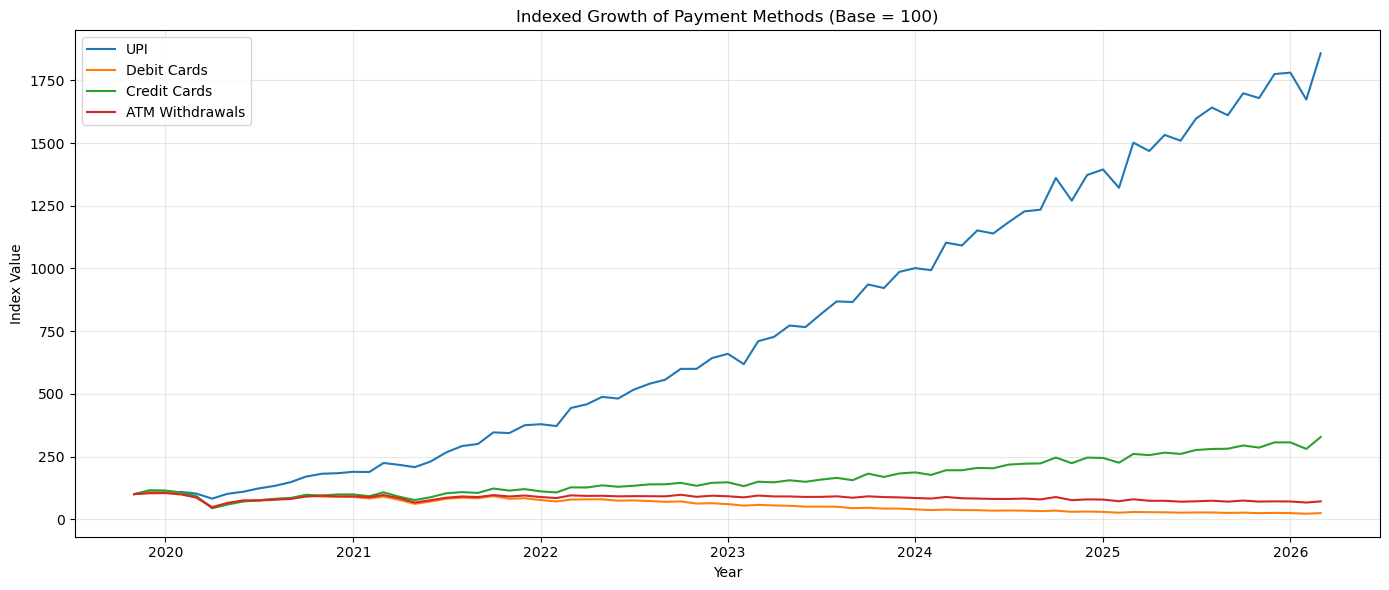

In [32]:
plt.figure(figsize=(14,6))

plt.plot(normalized['Month'], normalized['UPI_Volume_inlakhs'], label='UPI')
plt.plot(normalized['Month'], normalized['Debit_Volume_inlakhs'], label='Debit Cards')
plt.plot(normalized['Month'], normalized['Credit_Volume_inlakhs'], label='Credit Cards')
plt.plot(normalized['Month'], normalized['ATM_Debit_Volume_inlakhs'], label='ATM Withdrawals')

plt.title('Indexed Growth of Payment Methods (Base = 100)')
plt.xlabel('Year')
plt.ylabel('Index Value')

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

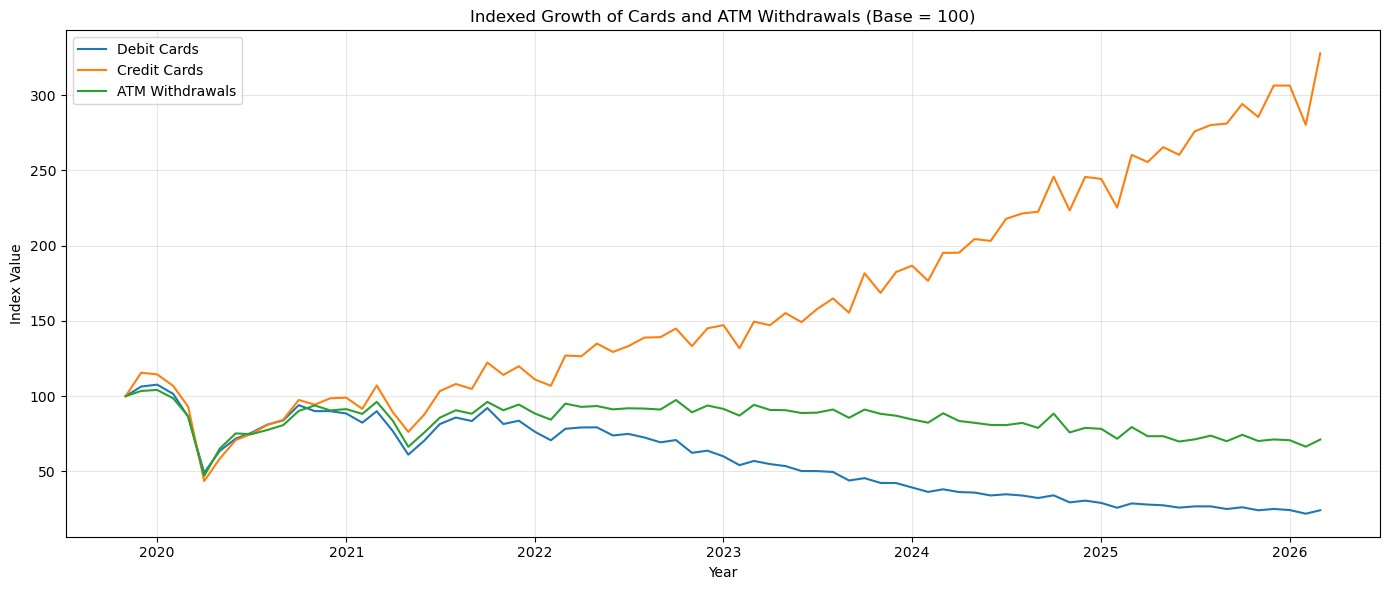

In [33]:
plt.figure(figsize=(14,6))

plt.plot(normalized['Month'], normalized['Debit_Volume_inlakhs'], label='Debit Cards')
plt.plot(normalized['Month'], normalized['Credit_Volume_inlakhs'], label='Credit Cards')
plt.plot(normalized['Month'], normalized['ATM_Debit_Volume_inlakhs'], label='ATM Withdrawals')

plt.title('Indexed Growth of Cards and ATM Withdrawals (Base = 100)')
plt.xlabel('Year')
plt.ylabel('Index Value')

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Observation: Indexed Growth of Payment Methods

The indexed growth chart compares payment methods using a common base value of 100 at the start of the period.

UPI shows the strongest growth by a wide margin, rising to more than 18 times its initial level by 2026. This confirms that UPI was the dominant growth driver in India's payment ecosystem during the study period.

Credit card transactions also increased steadily, growing to more than three times their initial level. This suggests that credit cards continued to expand alongside UPI rather than being replaced by it.

Debit card transactions show a clear long-term decline, falling well below their starting level. This supports the earlier correlation finding that debit card usage declined as UPI adoption increased.

ATM debit withdrawals also declined, but at a much slower rate than debit card payments. This indicates that cash withdrawal behavior reduced moderately, but not as sharply as debit card transaction usage.

### Key Insight

UPI did not uniformly replace all payment methods. Its rise coincided with a sharp decline in debit card transactions, a moderate decline in ATM withdrawals, and continued growth in credit card transactions. This suggests that UPI's impact was uneven across payment methods, with debit cards appearing most vulnerable to substitution.

# EDA Question 2
Are UPI, debit cards, credit cards, and ATM withdrawals serving the same kind of transaction?

In [36]:
payments['UPI_ATV'] = (
    payments['UPI_Value_inCr'] * 100
) / payments['UPI_Volume_inlakhs']

payments['Debit_ATV'] = (
    payments['Debit_Value_inCr'] * 100
) / payments['Debit_Volume_inlakhs']

payments['Credit_ATV'] = (
    payments['Credit_Value_inCr'] * 100
) / payments['Credit_Volume_inlakhs']

payments['ATM_Debit_ATV'] = (
    payments['ATM_Debit_Value_inCr'] * 100
) / payments['ATM_Debit_Volume_inlakhs']

In [37]:
payments.columns

Index(['Month', 'UPI_Volume_inlakhs', 'UPI_Value_inCr',
       'Credit_Volume_inlakhs', 'Credit_Value_inCr', 'Debit_Volume_inlakhs',
       'Debit_Value_inCr', 'ATM_Debit_Volume_inlakhs', 'ATM_Debit_Value_inCr',
       'UPI_ATV', 'Debit_ATV', 'Credit_ATV', 'ATM_Debit_ATV'],
      dtype='object')

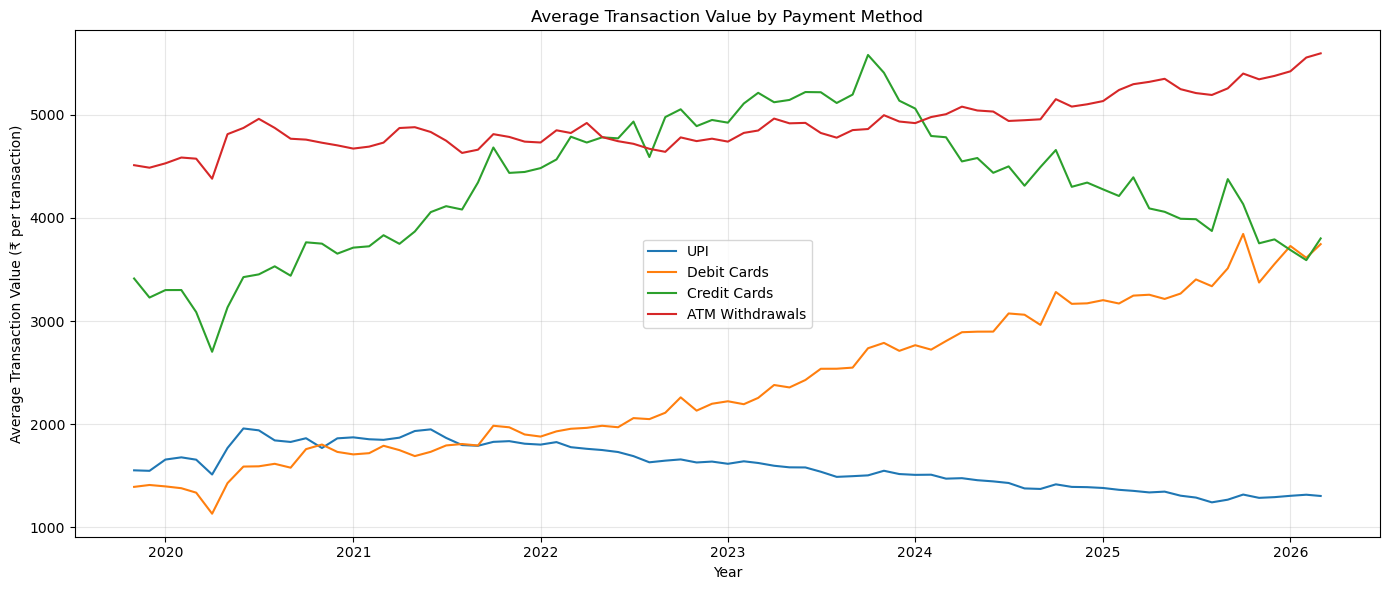

In [39]:
plt.figure(figsize=(14,6))

plt.plot(payments['Month'], payments['UPI_ATV'], label='UPI')
plt.plot(payments['Month'], payments['Debit_ATV'], label='Debit Cards')
plt.plot(payments['Month'], payments['Credit_ATV'], label='Credit Cards')
plt.plot(payments['Month'], payments['ATM_Debit_ATV'], label='ATM Withdrawals')

plt.title('Average Transaction Value by Payment Method')
plt.xlabel('Year')
plt.ylabel('Average Transaction Value (₹ per transaction)')

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [40]:
payments.to_csv("../data/processed/payment_ecosystem_clean.csv", index=False)

### Observation: Average Transaction Value by Payment Method

The average transaction value differs significantly across payment methods.

UPI consistently records the lowest average transaction value among the payment methods analyzed. This suggests that UPI is primarily used for frequent, everyday transactions rather than high-value payments.

Credit card transactions show a much higher average transaction value compared to UPI. This supports the idea that credit cards continued to grow alongside UPI because they serve different use cases, such as larger purchases, credit access, rewards, and deferred payments.

Debit card average transaction value increased over time, despite debit card transaction volume declining. This suggests that debit cards may have lost frequent low-value transaction use cases, while remaining relevant for relatively larger transactions.

ATM withdrawals show the highest average transaction value. However, this represents average cash withdrawn per ATM transaction, not a purchase payment. The rise in ATM withdrawal value suggests that cash withdrawal frequency may have declined, but users continued to withdraw larger amounts when using ATMs.

### Key Insight

UPI appears to have transformed everyday payment behavior rather than replacing all payment methods equally. Its low and stable average transaction value suggests that it became dominant for frequent small-to-medium transactions, while credit cards and ATM withdrawals continued to serve higher-value use cases.

# Final Summary: Is UPI Changing the Way India Pays?

The analysis suggests that UPI has significantly changed India's payment ecosystem, but its impact has not been uniform across all payment methods.

UPI transaction volume grew dramatically between 2019 and 2026, far outpacing debit cards, credit cards, and ATM withdrawals. This confirms that UPI became the dominant growth driver in India's retail digital payments ecosystem.

Debit card transaction volume declined sharply during the same period. The strong negative correlation between UPI volume and debit card volume suggests that debit card payments may have been the most affected by UPI adoption. However, this relationship should be interpreted as association rather than proof of direct causation.

ATM withdrawals using debit cards also declined, but the relationship with UPI was weaker compared to debit card payments. This suggests that UPI may have reduced some dependence on cash withdrawals, but cash usage did not decline as sharply as debit card payment usage.

Credit card transactions grew strongly alongside UPI. This challenges the assumption that UPI replaced all card payments. Instead, the data suggests that credit cards continued to serve different use cases, such as larger purchases, credit-based spending, rewards, and deferred payments.

Average transaction value analysis supports this interpretation. UPI consistently had the lowest average transaction value, indicating its role in frequent everyday payments. Credit cards, debit cards, and ATM withdrawals had higher average transaction values, suggesting that they continued to serve larger-value transaction needs.

## Key Insight

UPI appears to have changed everyday payment behavior in India rather than replacing all payment methods equally. Its rise coincided with a sharp decline in debit card transactions, moderate decline in ATM withdrawals, and continued growth in credit cards.

This suggests that UPI's strongest impact was on frequent low-to-medium value transactions, especially those previously served by debit cards or cash, while credit cards remained relevant for higher-value and credit-based spending.

# Limitations

This analysis is based on aggregate monthly payment system data. While correlations and trends reveal strong associations, they do not prove causation.

The decline in debit card transactions may be influenced by multiple factors, including UPI adoption, changing consumer preferences, merchant acceptance, COVID-related behavior changes, and broader digital payment infrastructure growth.

ATM withdrawal data is used as a proxy for cash usage, but it does not capture all cash transactions in the economy.